In [174]:
import importlib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import model_functions
import utils
importlib.reload(model_functions)
importlib.reload(utils)

from model_functions import load_transition_matrix, gen_risk_matrix, gen_transition_probabilities, run_markov_cohort, \
    run_mc_sim, calculate_outcomes, plot_trace, load_costs, STAGE_ORDER, run_comparison

from utils import gen_cea

In [175]:
# calculating progression risk reduction from ESSENCE trial data
prog_prop_tx = 0.206
prog_prop_placebo = 0.356

prog_prop_tx_ann = prog_prop_tx * 52 / 72
prog_prop_placebo_ann = prog_prop_placebo * 52 / 72

prog_rate_tx = 1 - np.exp(-prog_prop_tx_ann)
prog_rate_placebo = 1 - np.exp(-prog_prop_placebo_ann)

pr_stg2_essence = prog_rate_tx / prog_rate_placebo

pr_stg2_essence

np.float64(0.6097424116233234)

In [176]:
# GLOBAL base values
initial_prevalence = [.628, 0.309, 0.035, 0.016, 0.012, 0,0,0,0,0]

rr = [1, 1.56]  # relative risk of regression with treatment
pr = [1, 0.6097424116233234] # relative risk of progression with treatment (calculated below)

baseline_tm_suffix = "_trial"



# Sensitivity Analyses

In [177]:
sensitivity_results = []

Running model for treatment: SOC
{'transition_suffix': '_trial', 'risk_attenuated_cycles': 6}
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  933674.6834294496
Discounted LY:  22.85891251756616
Discounted QALY:  19.403789507741067
Discounted Cost:  435714.30798612797
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'risk_attenuated_cycles': 6}
Total LY:  42.989316612633786
Total QALY:  35.58494776551193
Total Cost:  939129.8185713931
Discounted LY:  22.988403945270374
Discounted QALY:  19.54267903322325
Discounted Cost:  440015.2707829928


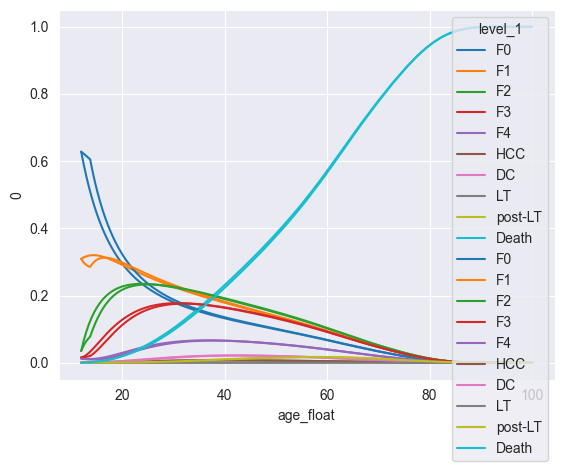

In [178]:
# Base Model
results, traces = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
                                 initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, 
                                 transition_suffix=baseline_tm_suffix, risk_attenuated_cycles=6)

sensitivity_results.append(['base', 'base', gen_cea(results).loc['Semaglutide', 'ICER']])

## Varying background re/progression rates

Running model for treatment: SOC
{'transition_suffix': '_obs_low', 'risk_attenuated_cycles': 6}
Total LY:  46.5551286966692
Total QALY:  39.06264109981659
Total Cost:  813828.3905384685
Discounted LY:  24.069980771418216
Discounted QALY:  20.73330573861231
Discounted Cost:  371233.96282636654
Running model for treatment: Semaglutide
{'transition_suffix': '_obs_low', 'risk_attenuated_cycles': 6}
Total LY:  46.64901208633172
Total QALY:  39.15840508708493
Total Cost:  821251.2159741017
Discounted LY:  24.10395169514386
Discounted QALY:  20.77162951051869
Discounted Cost:  379157.3255291239
Running model for treatment: SOC
{'transition_suffix': '_obs_high', 'risk_attenuated_cycles': 6}
Total LY:  45.88158877770525
Total QALY:  38.41582766985317
Total Cost:  833134.6270929938
Discounted LY:  23.864744635081443
Discounted QALY:  20.502886639669217
Discounted Cost:  382087.588135449
Running model for treatment: Semaglutide
{'transition_suffix': '_obs_high', 'risk_attenuated_cycles': 6}
Total

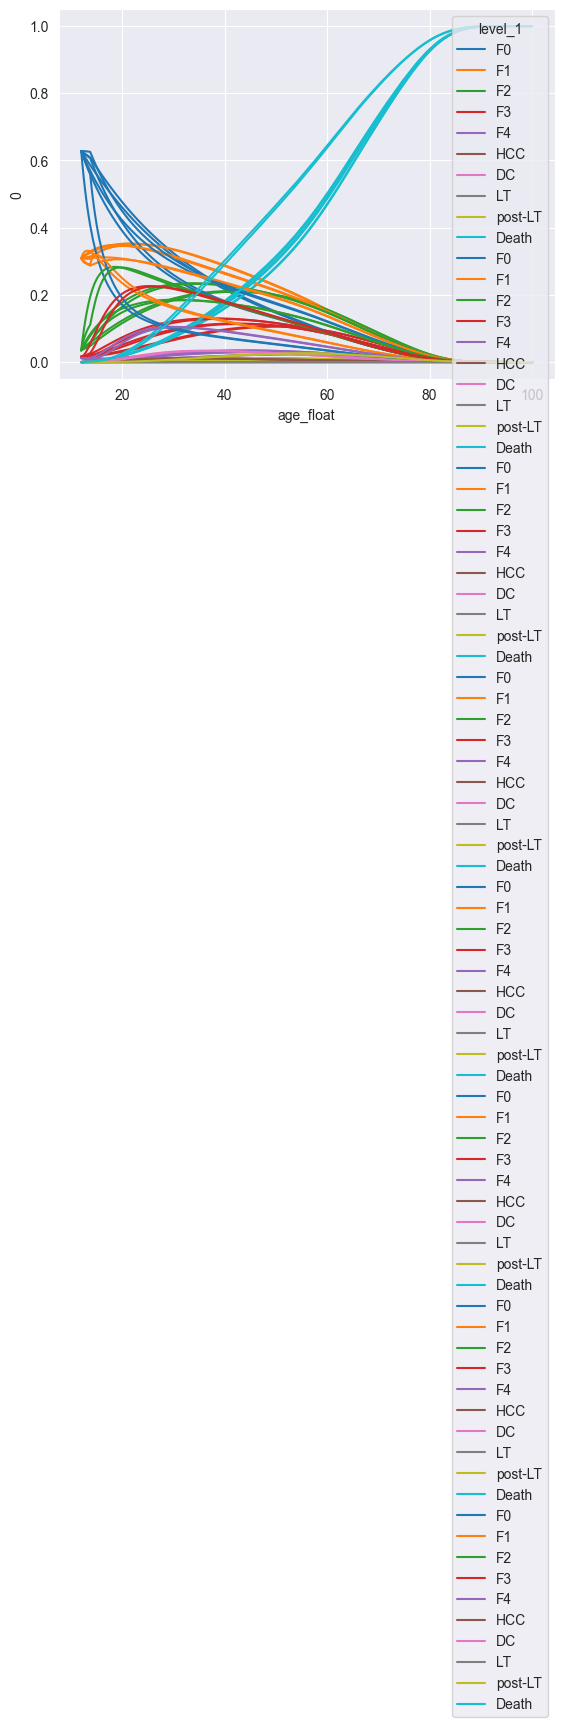

In [179]:
# TODO should include other rates in low/high as well (DC, HCC, liver transplant)

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, 
               transition_suffix='_obs_low', risk_attenuated_cycles=6)
sensitivity_results.append(['progression_rate_obs', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, 
               transition_suffix='_obs_high', risk_attenuated_cycles=6)
sensitivity_results.append(['progression_rate_obs', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, 
               transition_suffix='_trial_low', risk_attenuated_cycles=6)
sensitivity_results.append(['progression_rate_trial', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, 
               transition_suffix='_trial_high', risk_attenuated_cycles=6)
sensitivity_results.append(['progression_rate_trial', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])


## Varying Discount Rate

Running model for treatment: SOC
{'transition_suffix': '_trial', 'discount_rate': 0.01, 'risk_attenuated_cycles': 6}
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  933674.6834294496
Discounted LY:  33.76262366253261
Discounted QALY:  28.185148450360654
Discounted Cost:  703963.7877858051
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'discount_rate': 0.01, 'risk_attenuated_cycles': 6}
Total LY:  42.989316612633786
Total QALY:  35.58494776551193
Total Cost:  939129.8185713931
Discounted LY:  33.995640193284984
Discounted QALY:  28.413299777063596
Discounted Cost:  708588.4255312466
Running model for treatment: SOC
{'transition_suffix': '_trial', 'discount_rate': 0.05, 'risk_attenuated_cycles': 6}
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  933674.6834294496
Discounted LY:  16.81166460224987
Discounted QALY:  14.459067562018957
Discounted Cost:  296793.5690028976
Running model for treatment: Semaglutide
{'tr

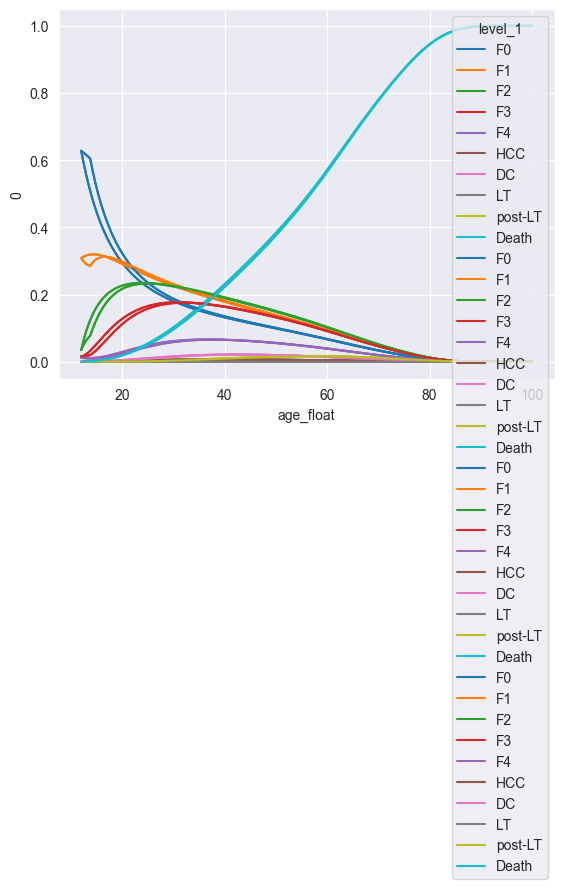

In [180]:
results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               discount_rate = 0.01, risk_attenuated_cycles=6)
sensitivity_results.append(['discount_rate', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               discount_rate = 0.05, risk_attenuated_cycles=6)
sensitivity_results.append(['discount_rate', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])

## Varying Treatment Costs

Running model for treatment: SOC
{'transition_suffix': '_trial', 'tx_cost_override': 2940}
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  933674.6834294496
Discounted LY:  22.85891251756616
Discounted QALY:  19.403789507741067
Discounted Cost:  435714.30798612797
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'tx_cost_override': 2940}
Total LY:  47.76373674815376
Total QALY:  40.40903593499704
Total Cost:  904628.5827478815
Discounted LY:  24.40589261218966
Discounted QALY:  21.123670256491238
Discounted Cost:  425372.8194802976
Running model for treatment: SOC
{'transition_suffix': '_trial', 'tx_cost_override': 13658}
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  933674.6834294496
Discounted LY:  22.85891251756616
Discounted QALY:  19.403789507741067
Discounted Cost:  435714.30798612797
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'tx_cost_override': 13658}
Total LY:  47.76373674

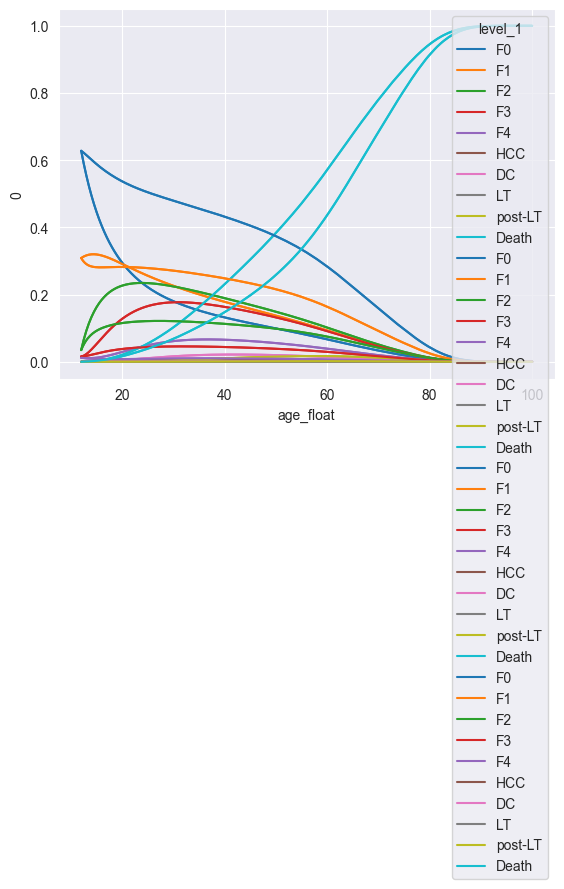

In [181]:
results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               tx_cost_override=2940)
sensitivity_results.append(['treatment_cost', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               tx_cost_override=13658)
sensitivity_results.append(['treatment_cost', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])

## Varying other costs

Running model for treatment: SOC
{'transition_suffix': '_trial', 'cost_suffix': '_low', 'tx_cost_override': 6829, 'risk_attenuated_cycles': 6}
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  787784.48474973
Discounted LY:  22.85891251756616
Discounted QALY:  19.403789507741067
Discounted Cost:  365710.45992798393
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'cost_suffix': '_low', 'tx_cost_override': 6829, 'risk_attenuated_cycles': 6}
Total LY:  42.989316612633786
Total QALY:  35.58494776551193
Total Cost:  794476.6494971452
Discounted LY:  22.988403945270374
Discounted QALY:  19.54267903322325
Discounted Cost:  371150.79962786945
Running model for treatment: SOC
{'transition_suffix': '_trial', 'cost_suffix': '_high', 'tx_cost_override': 6829, 'risk_attenuated_cycles': 6}
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  1111843.4796096014
Discounted LY:  22.85891251756616
Discounted QALY:  19.403789507741067
Di

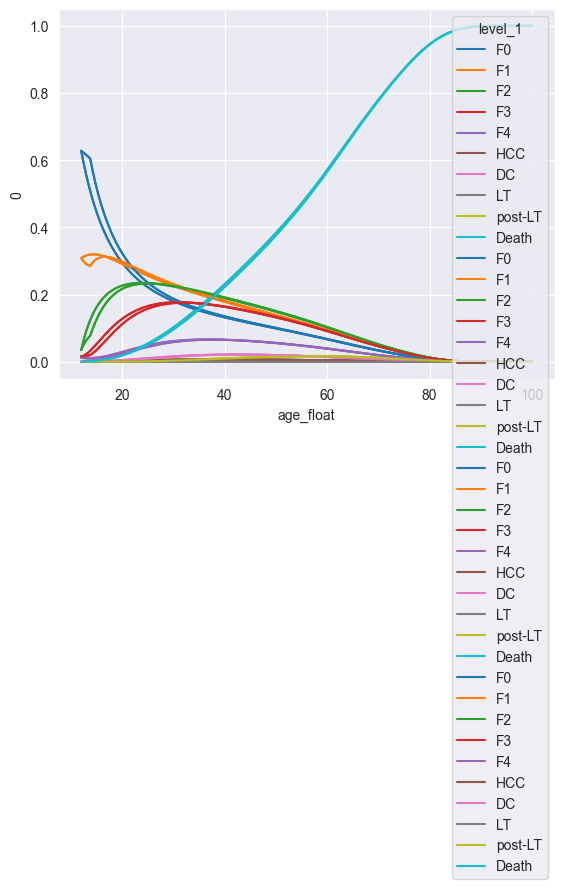

In [182]:
results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
                            cost_suffix='_low', tx_cost_override=6829, risk_attenuated_cycles=6)
sensitivity_results.append(['cost', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
                            cost_suffix='_high', tx_cost_override=6829, risk_attenuated_cycles=6)
sensitivity_results.append(['cost', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])

## Varying QALYs

Running model for treatment: SOC
{'transition_suffix': '_trial', 'qaly_stage_suffix': '_low', 'qaly_age_suffix': '_low', 'risk_attenuated_cycles': 6}
Total LY:  42.66622681668631
Total QALY:  32.353789723980576
Total Cost:  933674.6834294496
Discounted LY:  22.85891251756616
Discounted QALY:  17.96166498965421
Discounted Cost:  435714.30798612797
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'qaly_stage_suffix': '_low', 'qaly_age_suffix': '_low', 'risk_attenuated_cycles': 6}
Total LY:  42.989316612633786
Total QALY:  32.67651246896582
Total Cost:  939129.8185713931
Discounted LY:  22.988403945270374
Discounted QALY:  18.123132642931502
Discounted Cost:  440015.2707829928
Running model for treatment: SOC
{'transition_suffix': '_trial', 'qaly_stage_suffix': '_high', 'qaly_age_suffix': '_high', 'risk_attenuated_cycles': 6}
Total LY:  42.66622681668631
Total QALY:  37.3505901150996
Total Cost:  933674.6834294496
Discounted LY:  22.85891251756616
Discounted QALY: 

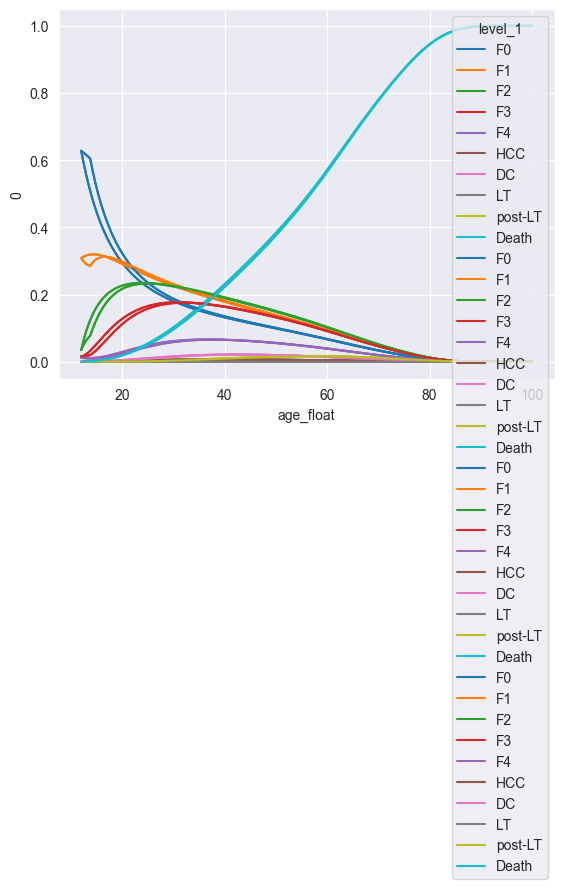

In [183]:
results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
                            qaly_stage_suffix='_low', qaly_age_suffix='_low', risk_attenuated_cycles=6)
sensitivity_results.append(['qalys', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
                            qaly_stage_suffix='_high', qaly_age_suffix='_high', risk_attenuated_cycles=6)
sensitivity_results.append(['qalys', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])

## Attenuated Risk

In [184]:
results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
                                 initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, 
                                 transition_suffix=baseline_tm_suffix, risk_attenuated_cycles=4*5, risk_decreases=True)

sensitivity_results.append(['attenuated_rr', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
                                 initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, 
                                 transition_suffix=baseline_tm_suffix, risk_attenuated_cycles=4*15, risk_decreases=True)

sensitivity_results.append(['attenuated_rr', 'mid', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
                                 initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, 
                                 transition_suffix=baseline_tm_suffix, risk_attenuated_cycles=4*25, risk_decreases=True)

sensitivity_results.append(['attenuated_rr', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])

Running model for treatment: SOC
{'transition_suffix': '_trial', 'risk_attenuated_cycles': 20, 'risk_decreases': True}


KeyboardInterrupt: 

## Varying Transition Hazard Ratio

Progression rates from Newsome Phase 2 trial

--0.1mg (daily): 
6/20, 
0/17, 
2/37

--0.2mg: 
4/15, 
0/13, 
0/39

--0.4mg: 
3/19, 
1/11, 
0/39

--Placebo: 
6/17, 
7/19, 
2/34

In [185]:
prog_prop_tx = (8+4+4) / (74 + 67 + 69)
prog_prop_placebo = 15 / 70

prog_prop_tx_ann = prog_prop_tx * 52 / 72
prog_prop_placebo_ann = prog_prop_placebo * 52 / 72

prog_rate_tx = 1 - np.exp(-prog_prop_tx_ann)
prog_rate_placebo = 1 - np.exp(-prog_prop_placebo_ann)

pr_newsome = prog_rate_tx / prog_rate_placebo
pr_newsome


np.float64(0.3734102296038241)

Running model for treatment: SOC
{'transition_suffix': '_trial', 'risk_attenuated_cycles': 6}
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  933674.6834294496
Discounted LY:  22.85891251756616
Discounted QALY:  19.403789507741067
Discounted Cost:  435714.30798612797
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'risk_attenuated_cycles': 6}
Total LY:  42.8338440477513
Total QALY:  35.4388006142029
Total Cost:  941033.8371053817
Discounted LY:  22.926230674856704
Discounted QALY:  19.475963069178963
Discounted Cost:  442368.5555858185
Running model for treatment: SOC
{'transition_suffix': '_trial', 'risk_attenuated_cycles': 6}
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  933674.6834294496
Discounted LY:  22.85891251756616
Discounted QALY:  19.403789507741067
Discounted Cost:  435714.30798612797
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'risk_attenuated_cycles': 6}
Total LY:  43

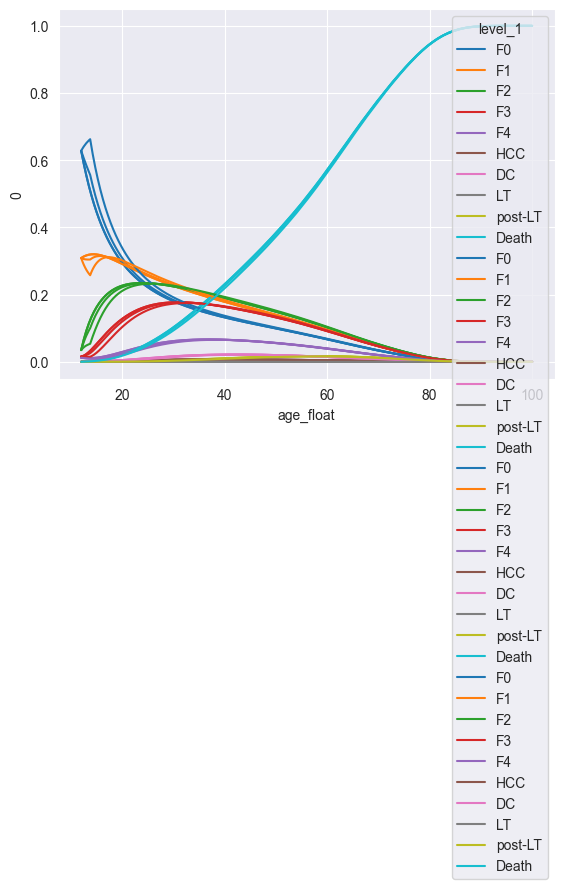

In [190]:
# Varying Transition Hazard Ratio TODO what to use for low and high?
low = 0.5
results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
                            initial_prevalence, ['SOC', 'Semaglutide'], 
                            rr=[(val - 1) * low + 1 for val in rr], 
                            pr=[1 - (1 - val) * low for val in pr],
                            transition_suffix=baseline_tm_suffix,
                            risk_attenuated_cycles=6)

sensitivity_results.append(['transition_hazard_ratio', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
                            initial_prevalence, ['SOC', 'Semaglutide'], 
                            rr=[(val - 1) * 1.5 + 1 for val in rr], 
                            pr=[1, pr_newsome],
                            transition_suffix=baseline_tm_suffix,
                            risk_attenuated_cycles=6)

sensitivity_results.append(['transition_hazard_ratio', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])



# Prevalence Variation

In [196]:
tmp = np.asarray(initial_prevalence)[1:] / 2
low_prevalence = [1 - sum(tmp)] + list(tmp)

tmp = np.asarray(initial_prevalence)[1:] * 2
high_prevalence = [1 - sum(tmp)] + list(tmp)

In [217]:
low_prevalence

[np.float64(0.8140000000000001),
 np.float64(0.1545),
 np.float64(0.0175),
 np.float64(0.008),
 np.float64(0.006),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

In [216]:
high_prevalence

[np.float64(0.256),
 np.float64(0.618),
 np.float64(0.07),
 np.float64(0.032),
 np.float64(0.024),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

Running model for treatment: SOC
{'transition_suffix': '_trial', 'risk_attenuated_cycles': 6}
Total LY:  43.08743009200361
Total QALY:  35.674218451879504
Total Cost:  928411.8868209552
Discounted LY:  23.030263560262718
Discounted QALY:  19.585360301890184
Discounted Cost:  428956.19859218417
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'risk_attenuated_cycles': 6}
Total LY:  43.34062886421577
Total QALY:  35.91379015670995
Total Cost:  934463.8737185036
Discounted LY:  23.1296422730249
Discounted QALY:  19.69331298310197
Discounted Cost:  434265.8397211724
Running model for treatment: SOC
{'transition_suffix': '_trial', 'risk_attenuated_cycles': 6}
Total LY:  41.82382026605171
Total QALY:  34.49565706145945
Total Cost:  944200.2766464367
Discounted LY:  22.516210432173043
Discounted QALY:  19.040647919442836
Discounted Cost:  449230.5267740154
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'risk_attenuated_cycles': 6}
Total LY:  4

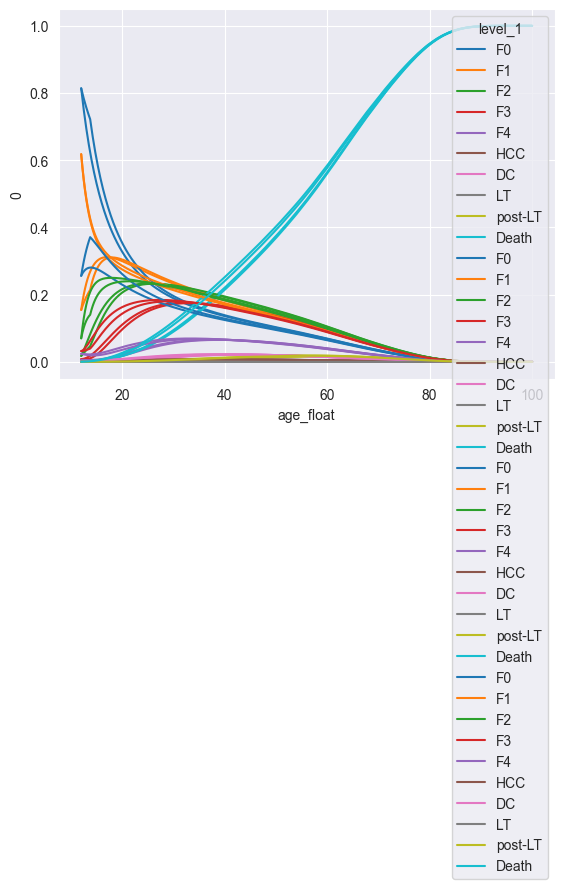

In [197]:
results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               low_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
                             risk_attenuated_cycles=6)
sensitivity_results.append(['prevalence', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               high_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
                             risk_attenuated_cycles=6)
sensitivity_results.append(['prevalence', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])

## Plot Tornado Diagram

In [212]:
sensitivity_df = pd.DataFrame(sensitivity_results, columns=['variable', 'value', 'icer'])

In [209]:
sensitivity_df

,variable,value,icer
0,base,base,30966.790202
1,progression_rate_obs,low,206747.987179
2,progression_rate_obs,high,104484.371599
3,progression_rate_trial,low,77003.479548
4,progression_rate_trial,high,11403.012340
5,discount_rate,low,20270.045379
6,discount_rate,high,50320.689973
7,treatment_cost,low,-6012.910205
8,treatment_cost,high,146080.400455
9,cost,low,39170.266303


In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def create_tornado_plot(sensitivity_df, threshold=None, figsize=(10, 8)):
    """
    Create a tornado plot from CEA sensitivity analysis results
    
    Parameters:
    -----------
    sensitivity_df : DataFrame with columns ['variable', 'value', 'icer']
                    - One row with variable='base', value='base'
                    - Pairs of rows for each parameter with value='low' and 'high'
    threshold : float, optional WTP threshold to display
    figsize : tuple, figure size
    """
    
    # Extract base case value
    base_value = sensitivity_df[sensitivity_df['value'] == 'base']['icer'].values[0]
    
    # Filter out base case and reshape
    sens_data = sensitivity_df[sensitivity_df['value'] != 'base'].copy()
    tornado_data = sens_data.pivot(index='variable', columns='value', values='icer')
    
    # Calculate range for sorting (absolute difference)
    tornado_data['range'] = abs(tornado_data['high'] - tornado_data['low'])
    tornado_data = tornado_data.sort_values('range', ascending=True)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    y_pos = np.arange(len(tornado_data))
    
    # Plot bars for each variable
    for i, (idx, row) in enumerate(tornado_data.iterrows()):
        low_val = row['low']
        high_val = row['high']
        
        # Find actual min and max (don't assume low < high)
        left_val = min(low_val, high_val)
        right_val = max(low_val, high_val)
        width = right_val - left_val
        
        # Single color bar - no transparency
        ax.barh(i, width, left=left_val, height=0.7,
                color='#3498db', edgecolor='black', linewidth=0.8)
        
        # Add value labels at the ends
        if low_val < high_val:
            ax.text(low_val - 1000, i, f'  Low: ${low_val/1000:.0f}K', 
                    va='center', ha='right', fontsize=10)
            ax.text(high_val + 1000, i, f'High: ${high_val/1000:.0f}K  ', 
                    va='center', ha='left', fontsize=10)
        else:
            ax.text(high_val - 1000, i, f'  High: ${high_val/1000:.0f}K', 
                    va='center', ha='right', fontsize=10)
            ax.text(low_val + 1000, i, f'Low: ${low_val/1000:.0f}K  ', 
                    va='center', ha='left', fontsize=10)
    
    # Base case line
    ax.axvline(x=base_value, color='black', linestyle='--', linewidth=2.5,
               label=f'Baseline Model: ${base_value/1000:.0f}K', zorder=10)
    
    # Optional WTP threshold
    if threshold:
        ax.axvline(x=threshold, color='green', linestyle=':', linewidth=2,
                   label=f'WTP Threshold: ${threshold/1000:.0f}K', zorder=10)
    
    # Formatting
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tornado_data.index, fontsize=12)
    ax.set_xlabel('Incremental Cost-Effectiveness Ratio ($/QALY)', 
                  fontsize=14, fontweight='bold')
    ax.set_title('One-Way Sensitivity Analysis - Tornado Diagram',
                 fontsize=16, fontweight='bold', pad=20)
    
    # Set x-axis limits
    low = min(tornado_data['low'].min(), tornado_data['high'].min())
    high = max(tornado_data['low'].max(), tornado_data['high'].max())
    ax.set_xlim(min(0, low*0.6-30000), high*1.2)
    
    # Grid - only x-axis, more subtle
    ax.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.5, color='gray')
    ax.grid(axis='y', visible=False)
    ax.set_axisbelow(True)
    
    # Format x-axis with larger ticks
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    ax.tick_params(axis='x', labelsize=12)
    
    # Legend
    ax.legend(loc='best', fontsize=18, framealpha=0.95)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    # Print summary
    print("\n" + "="*60)
    print("SENSITIVITY ANALYSIS SUMMARY")
    print("="*60)
    print(f"\nBase Case ICER: ${base_value:,.0f}")
    print(f"\nParameters Ranked by Impact:")
    print("-"*60)
    
    summary = tornado_data[['low', 'high', 'range']].sort_values('range', ascending=False)
    for idx, row in summary.iterrows():
        print(f"{idx:30s} | Range: ${row['range']:,.0f}")
        print(f"{'':30s} | Low: ${row['low']:,.0f}  High: ${row['high']:,.0f}")
        print("-"*60)
    
    return fig, ax

In [213]:
vals = {'progression_rate_obs': 'Transition Probs \n(Observation Data)',
        'progression_rate_trial': 'Transition Probs \n(Trial Data)',
        'discount_rate': 'Discount Rate',
        'treatment_cost': 'Treatment Cost',
        'cost': 'State Costs',
        'qalys': 'QALYs',
        'transition_hazard_ratio': 'Drug Efficacy',
        'prevalence': 'Initial Prevalence'}
sensitivity_df['variable'] = sensitivity_df['variable'].replace(vals)


SENSITIVITY ANALYSIS SUMMARY

Base Case ICER: $30,967

Parameters Ranked by Impact:
------------------------------------------------------------
Treatment Cost                 | Range: $152,093
                               | Low: $-6,013  High: $146,080
------------------------------------------------------------
Transition Probs 
(Observation Data) | Range: $102,264
                               | Low: $206,748  High: $104,484
------------------------------------------------------------
Drug Efficacy                  | Range: $83,570
                               | Low: $92,198  High: $8,628
------------------------------------------------------------
Transition Probs 
(Trial Data) | Range: $65,600
                               | Low: $77,003  High: $11,403
------------------------------------------------------------
Initial Prevalence             | Range: $37,810
                               | Low: $49,185  High: $11,375
-------------------------------------------------------

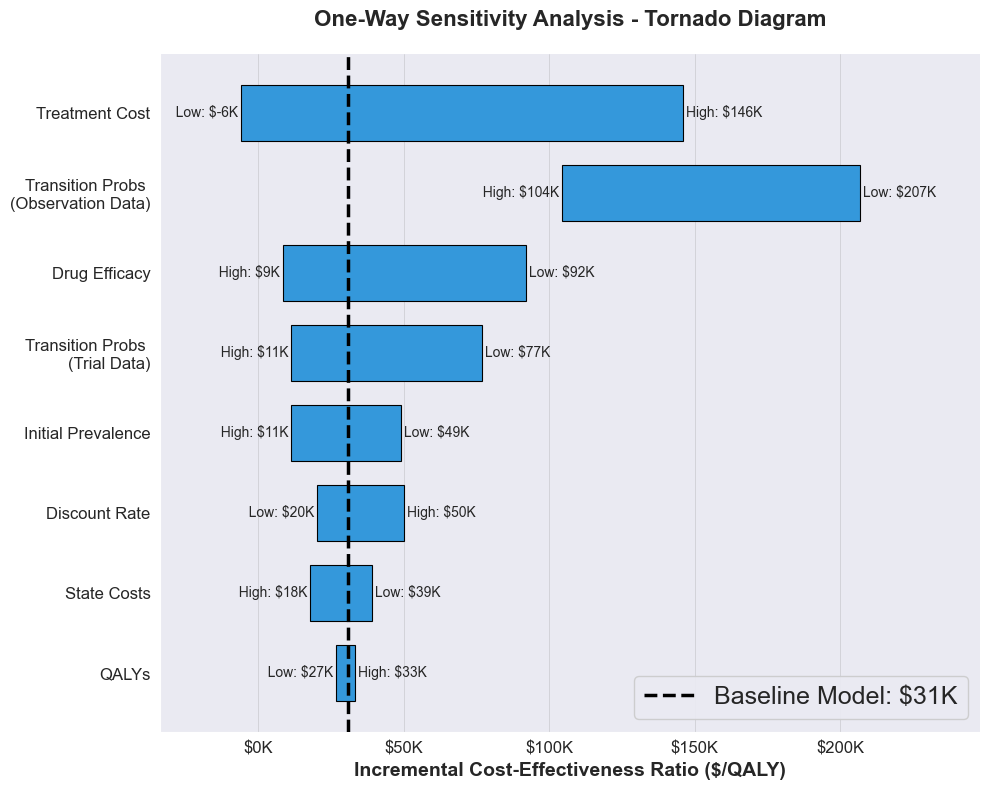

In [214]:
fig, ax = create_tornado_plot(sensitivity_df.drop_duplicates())


In [215]:
fig.savefig('tornado_plot.png', dpi=300)

# TODO
- Get better idea of change in cost and QALYs for additional treatment
    - Change in age
    - Change in efficacy timeline (hard-stop)
- Run 3-way sensitivity analysis
    - Efficacy timeline (72 wks, 5 yrs, 20 yrs, lifetime) - separately attenuated?
    - Treatment cost (current, Trump proposed)
    - Progression assumptions (1 -> Newsome estimate)

# Make CEA plot from changing age starts

Running model for treatment: SOC
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  933674.6834294496
Discounted LY:  22.85891251756616
Discounted QALY:  19.403789507741067
Discounted Cost:  435714.30798612797
Running model for treatment: Semaglutide
Total LY:  42.989316612633786
Total QALY:  35.58494776551193
Total Cost:  939129.8185713931
Discounted LY:  22.988403945270374
Discounted QALY:  19.54267903322325
Discounted Cost:  440015.2707829928
Running model for treatment: SOC
Total LY:  40.522645006054425
Total QALY:  33.372542415900654
Total Cost:  891436.6733741704
Discounted LY:  22.227320811677323
Discounted QALY:  18.777461168844052
Discounted Cost:  428064.9989683548
Running model for treatment: Semaglutide
Total LY:  40.8216932713292
Total QALY:  33.65473417628043
Total Cost:  896535.7654417414
Discounted LY:  22.35051836732563
Discounted QALY:  18.90992650537151
Discounted Cost:  432364.9279701297
Running model for treatment: SOC
Total LY:  38.4382461525

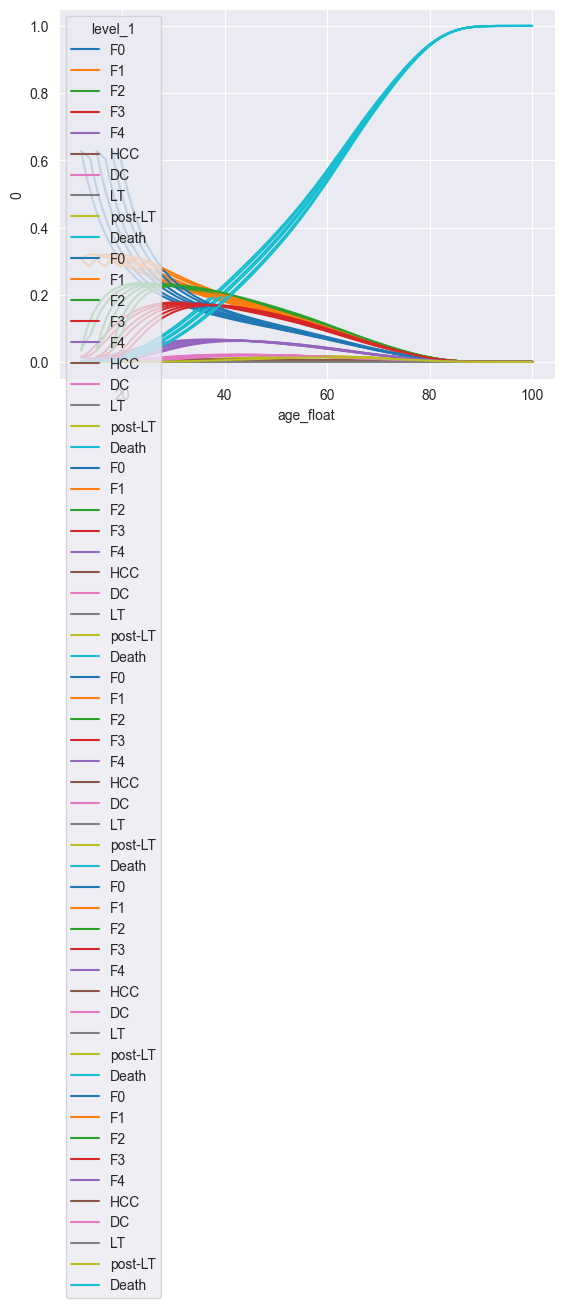

In [25]:
results_age_12, trace_age_12 = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               starting_age=12, risk_attenuated_cycles=6)

results_age_15, trace_age_15 = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               starting_age=15, risk_attenuated_cycles=6)

results_age_18, trace_age_18 = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               starting_age=18, risk_attenuated_cycles=6)

In [29]:
cea_12 = gen_cea(results_age_12)
cea_12['age_start'] = 12
cea_15 = gen_cea(results_age_15)
cea_15['age_start'] = 15
cea_18 = gen_cea(results_age_18)
cea_18['age_start'] = 18

cea_age = pd.concat([cea_12, cea_15, cea_18])

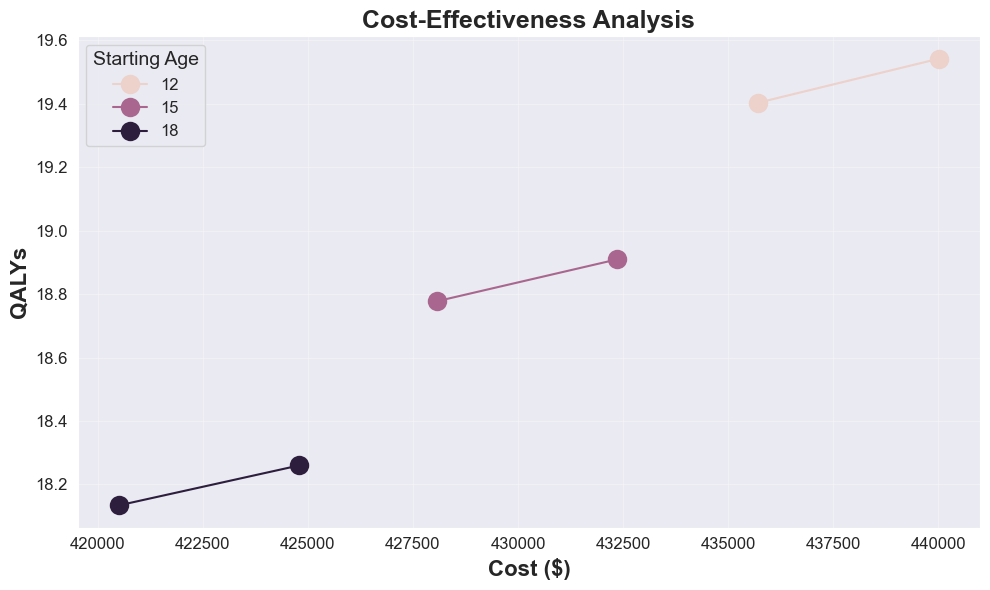

In [133]:
fig = plt.figure(figsize=(10, 6))

# marker size large for visibility
sns.lineplot(cea_age, x='Cost', y='QALY', hue='age_start', 
             marker='o', markers=True, markeredgewidth=0, 
             dashes=False, markersize=14)

plt.xlabel('Cost ($)', fontsize=16, fontweight='bold')
plt.ylabel('QALYs', fontsize=16, fontweight='bold')
plt.title('Cost-Effectiveness Analysis', fontsize=18, fontweight='bold')
plt.legend(title='Starting Age', fontsize=12, title_fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('cea_age_plot.png', dpi=300)
plt.show()

In [65]:
tmp = cea_age.reset_index().set_index(['index', 'age_start'])
base_values = tmp.loc['SOC'][['QALY', 'Cost']].loc[tmp.loc['SOC'].index.repeat(2)]
tmp_final = (tmp[['QALY', 'Cost']] - base_values.values).join(tmp[['ICER']])
tmp_final.iloc[[0,1,3,5]]

QALY         Cost          ICER
index       age_start                                     
SOC         12         0.000000     0.000000  22455.114132
Semaglutide 12         0.138890  4300.962797  30966.790202
            15         0.132465  4299.929002  32460.786456
            18         0.126012  4290.615596  34049.375031

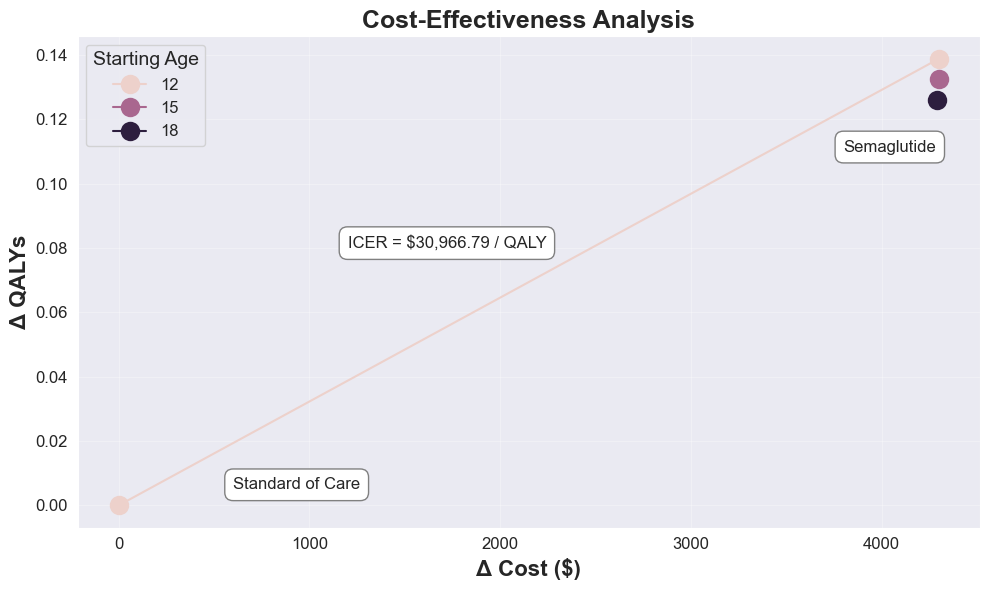

In [132]:
fig = plt.figure(figsize=(10, 6))

sns.lineplot(tmp_final.iloc[[0,1,3,5]].reset_index(), x='Cost', y='QALY', hue='age_start', 
             marker='o', dashes=False, markersize=14, markeredgewidth=0)
plt.xlabel('Δ Cost ($)', fontsize=16, fontweight='bold')
plt.ylabel('Δ QALYs', fontsize=16, fontweight='bold')
plt.title('Cost-Effectiveness Analysis', fontsize=18, fontweight='bold')
plt.legend(title='Starting Age', fontsize=12, title_fontsize=14)

plt.annotate('Standard of Care', 
             xy=(0, 0), 
             xytext=(600, 0.005),
             fontsize=12,
             # arrowprops=dict(arrowstyle='->', lw=1.5, edgecolor='gray'),
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray'))
plt.annotate('Semaglutide', 
             xy=tmp_final.iloc[1][['Cost', 'QALY']].values,
             xytext=(3800, 0.11),
             fontsize=12,
             # arrowprops=dict(arrowstyle='->', lw=1.5, edgecolor='gray'),
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray'))
plt.annotate('ICER = $30,966.79 / QALY', 
             xy=tmp_final.iloc[1][['Cost', 'QALY']].values,
             xytext=(1200, 0.08),
             fontsize=12,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray'))

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('cea_age_plot.aligned.png', dpi=300)

plt.show()

# 4-way sensitivity analysis

Calculate ICER for:
- Cost (current, Trump proposed)
- Changing the underlying transition probabilities (trial low, trial, trial high)
- Efficacy timeline (72 wks, 5 yrs, 20 yrs, lifetime)
- Different hazard ratios (base, *0.75, *0.5, *0.25) ?  

In [135]:
def reduce_efficacy(rr_base, pr_base, factor):
    rr_new = [(val - 1) * factor + 1 for val in rr_base]
    pr_new = [1 - (1 - val) * factor for val in pr_base]
    return rr_new, pr_new

In [169]:
# tx_cost_override
costs = [2940, 6829]

transition_sources = ['_trial_low', '_trial', '_trial_high']

efficacy_durations = [6, 4*5, 4*20, None]  # in years

hr_options = [reduce_efficacy(rr, pr, factor) for factor in [1, 0.75, 0.5, 0.25]]

In [170]:
multiway_sens = []
for c in costs:
    for t in transition_sources:
        for e in efficacy_durations:
            for i, (rr_mod, pr_mod) in enumerate(hr_options):
                hr_factor = [1, 0.75, 0.5, 0.25][i]
                print(f"\nRunning {c}, {t}, {e}, {hr_factor}")
                results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
                                 initial_prevalence, ['SOC', 'Semaglutide'], rr=rr_mod, pr=pr_mod, 
                                 transition_suffix=t, tx_cost_override=c,
                                 risk_attenuated_cycles=e, plot=False)
                cea_res = gen_cea(results)
                multiway_sens.append(cea_res.loc['Semaglutide'].to_dict() | 
                                     {'cost_scenario': c,
                                      'transition_source': t,
                                      'efficacy_duration': e if e is not None else 'lifetime',
                                      'hr_factor':hr_factor})
multiway_sens_df = pd.DataFrame(multiway_sens)



Running 2940, _trial_low, 6, 1
Running model for treatment: SOC
Total LY:  45.37167009839376
Total QALY:  37.88147804897763
Total Cost:  848299.9841436748
Discounted LY:  23.702459665280678
Discounted QALY:  20.304416538538728
Discounted Cost:  390413.5210192754
Running model for treatment: Semaglutide
Total LY:  45.566201401036494
Total QALY:  38.07171374251702
Total Cost:  849218.0801605647
Discounted LY:  23.77599173563921
Discounted QALY:  20.38698755975172
Discounted Cost:  391534.9532772914

Running 2940, _trial_low, 6, 0.75
Running model for treatment: SOC
Total LY:  45.37167009839376
Total QALY:  37.88147804897763
Total Cost:  848299.9841436748
Discounted LY:  23.702459665280678
Discounted QALY:  20.304416538538728
Discounted Cost:  390413.5210192754
Running model for treatment: Semaglutide
Total LY:  45.51950140917162
Total QALY:  38.02602388424004
Total Cost:  849971.7907577557
Discounted LY:  23.758374847721033
Discounted QALY:  20.367208178366887
Discounted Cost:  392214.5

In [171]:
multiway_sens_df.to_csv('multiway_sensitivity_results.csv', index=False)

In [172]:
multiway_sens_df

,QALY,Cost,Delta_Cost,Delta_QALY,ICER,cost_scenario,transition_source,efficacy_duration,hr_factor
0,20.386988,391534.953277,1121.432258,0.082571,13581.426529,2940,_trial_low,6,1.00
1,20.367208,392214.517184,1800.996164,0.062792,28682.101139,2940,_trial_low,6,0.75
2,20.346862,392913.653241,2500.132221,0.042445,58902.332268,2940,_trial_low,6,0.50
3,20.325936,393632.785256,3219.264236,0.021519,149599.565633,2940,_trial_low,6,0.25
4,20.539378,395385.556662,4972.035642,0.234962,21161.055551,2940,_trial_low,20,1.00
...,...,...,...,...,...,...,...,...,...
91,18.915638,562583.367706,73080.233857,0.665552,109803.942184,6829,_trial_high,80,0.25
92,20.950365,527629.572911,38126.439062,2.700280,14119.441265,6829,_trial_high,lifetime,1.00
93,20.548158,544938.032643,55434.898794,2.298073,24122.342075,6829,_trial_high,lifetime,0.75
94,19.964123,569768.215004,80265.081155,1.714037,46828.081220,6829,_trial_high,lifetime,0.50


/Users/csmess/PycharmProjects/hrp_392/venv_cea/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/csmess/PycharmProjects/hrp_392/venv_cea/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/csmess/PycharmProjects/hrp_392/venv_cea/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/csmess/PycharmProjects/hrp_392/venv_cea/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradi

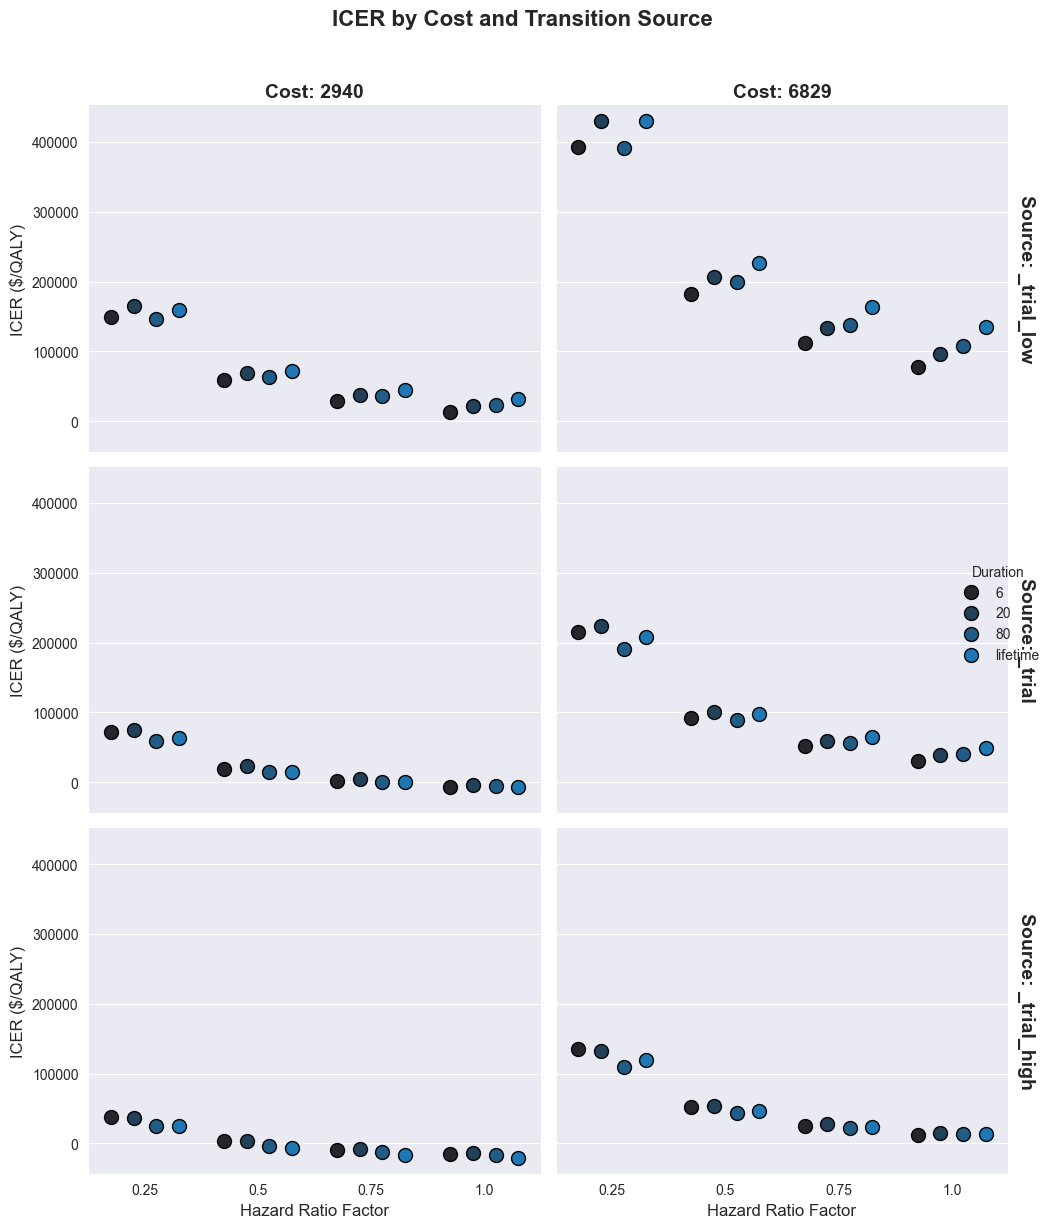

In [173]:
# Create FacetGrid
g = sns.FacetGrid(multiway_sens_df, row='transition_source', col='cost_scenario', 
                  height=4, aspect=1.2, margin_titles=True)

# Map the stripplot
g.map_dataframe(sns.stripplot, x='hr_factor', y='ICER', hue='efficacy_duration',
                dodge=True, s=10, linewidth=1, edgecolor='black')

# Formatting
g.set_axis_labels('Hazard Ratio Factor', 'ICER ($/QALY)', fontsize=12)
g.set_titles(row_template='Source: {row_name}', col_template='Cost: {col_name}',
             size=14, weight='bold')
g.figure.suptitle('ICER by Cost and Transition Source', 
                  fontsize=16, fontweight='bold', y=1.02)

# Add legend
g.add_legend(title='Duration', fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# TODO Do 4-way on 12-age compared to 18-age ICER?